In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


In [2]:
X_train = train_df["text"]
y_train = train_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

Text preprocessing

In [3]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [4]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [7]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_test_tfidf = tfidf.transform(X_test_clean)

In [8]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (10003, 10292)
Testing TF-IDF shape: (3080, 10292)


ML Models

Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

Naive Bayes

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

SVM

In [11]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

Comparing the models

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

models_predictions = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred
}

baseline_results = []

for name, predictions in models_predictions.items():

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_test, predictions)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,SVM,0.890584,0.894307,0.890584,0.890565
3,Random Forest,0.860714,0.867881,0.860714,0.860607
0,Logistic Regression,0.858766,0.868082,0.858766,0.858061
1,Naive Bayes,0.799026,0.832924,0.799026,0.785743


Hyperparameter Tuning

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

Tune Logistic Regression

In [15]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=2000))
])

lr_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.95, 1.0],
    "classifier__C": [0.1, 1, 4, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_clean, y_train)

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest CV Macro F1:")
print(lr_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/Users/movvahimasameera/Desktop/innomatics/Machine Learning/text_data_project/venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters:
{'classifier__C': 10, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

Best CV Macro F1:
0.8733459932348416


Tune Naive Bayes

In [16]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

nb_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.95, 1.0],
    "classifier__alpha": [0.01, 0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_params,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_clean, y_train)

print("Best Parameters:")
print(nb_grid.best_params_)

print("\nBest CV Macro F1:")
print(nb_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/Users/movvahimasameera/Desktop/innomatics/Machine Learning/text_data_project/venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters:
{'classifier__alpha': 0.01, 'tfidf__max_df': 0.95, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Macro F1:
0.8305756575521123


Tune SVM

In [17]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC())
])

svm_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.95, 1.0],
    "classifier__C": [0.1, 0.5, 1, 2, 4]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_clean, y_train)

print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest CV Macro F1:")
print(svm_grid.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best Parameters:
{'classifier__C': 1, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

Best CV Macro F1:
0.870938860301005


Tune Random Forest

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.95, 1.0],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 20, 40],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_clean, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Macro F1:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


/Users/movvahimasameera/Desktop/innomatics/Machine Learning/text_data_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/movvahimasameera/Desktop/innomatics/Machine Learning/text_data_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/movvahimasameera/Desktop/innomatics/Machine Learning/text_data_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

Best CV Macro F1:
0.8404278397418463


Comparing tuned models

In [22]:
tuned_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Naive Bayes": nb_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test_clean)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_test, y_pred)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="Macro F1",
    ascending=False
)

tuned_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.900000,0.904243,0.900000,0.900092
2,SVM,0.895130,0.899101,0.895130,0.895039
3,Random Forest,0.875325,0.880600,0.875325,0.874845
1,Naive Bayes,0.870779,0.875142,0.870779,0.870530


Comparing Baseline vs Tuned

In [23]:
comparison_df = baseline_results_df.merge(
    tuned_results_df,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

comparison_df["F1 Improvement"] = (
    comparison_df["Macro F1_Tuned"] -
    comparison_df["Macro F1_Baseline"]
)

comparison_df = comparison_df.sort_values(
    by="Macro F1_Tuned",
    ascending=False
)

comparison_df

,Model,Accuracy_Baseline,Macro Precision_Baseline,Macro Recall_Baseline,Macro F1_Baseline,Accuracy_Tuned,Macro Precision_Tuned,Macro Recall_Tuned,Macro F1_Tuned,F1 Improvement
0,Logistic Regression,0.858766,0.868082,0.858766,0.858061,0.900000,0.904243,0.900000,0.900092,0.042031
2,SVM,0.890584,0.894307,0.890584,0.890565,0.895130,0.899101,0.895130,0.895039,0.004474
3,Random Forest,0.860714,0.867881,0.860714,0.860607,0.875325,0.880600,0.875325,0.874845,0.014238
1,Naive Bayes,0.799026,0.832924,0.799026,0.785743,0.870779,0.875142,0.870779,0.870530,0.084787


best tuned model

In [24]:
final_model = lr_grid.best_estimator_

final_predictions = final_model.predict(X_test_clean)

print("Final model:", final_model)

Final model: Pipeline(steps=[('tfidf', TfidfVectorizer(max_df=0.95)),
                ('classifier', LogisticRegression(C=10, max_iter=2000))])


classification report

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_predictions,
    zero_division=0
))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.93      0.93      0.93        40
                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.97      0.95      0.96        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.71      0.75      0.73        40
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        40
                         beneficiary_not_allowed       0.97      0.90      0.94        40
                                 cancel_transfer       0.97      0.95      0.96        40
         

confusion matrix

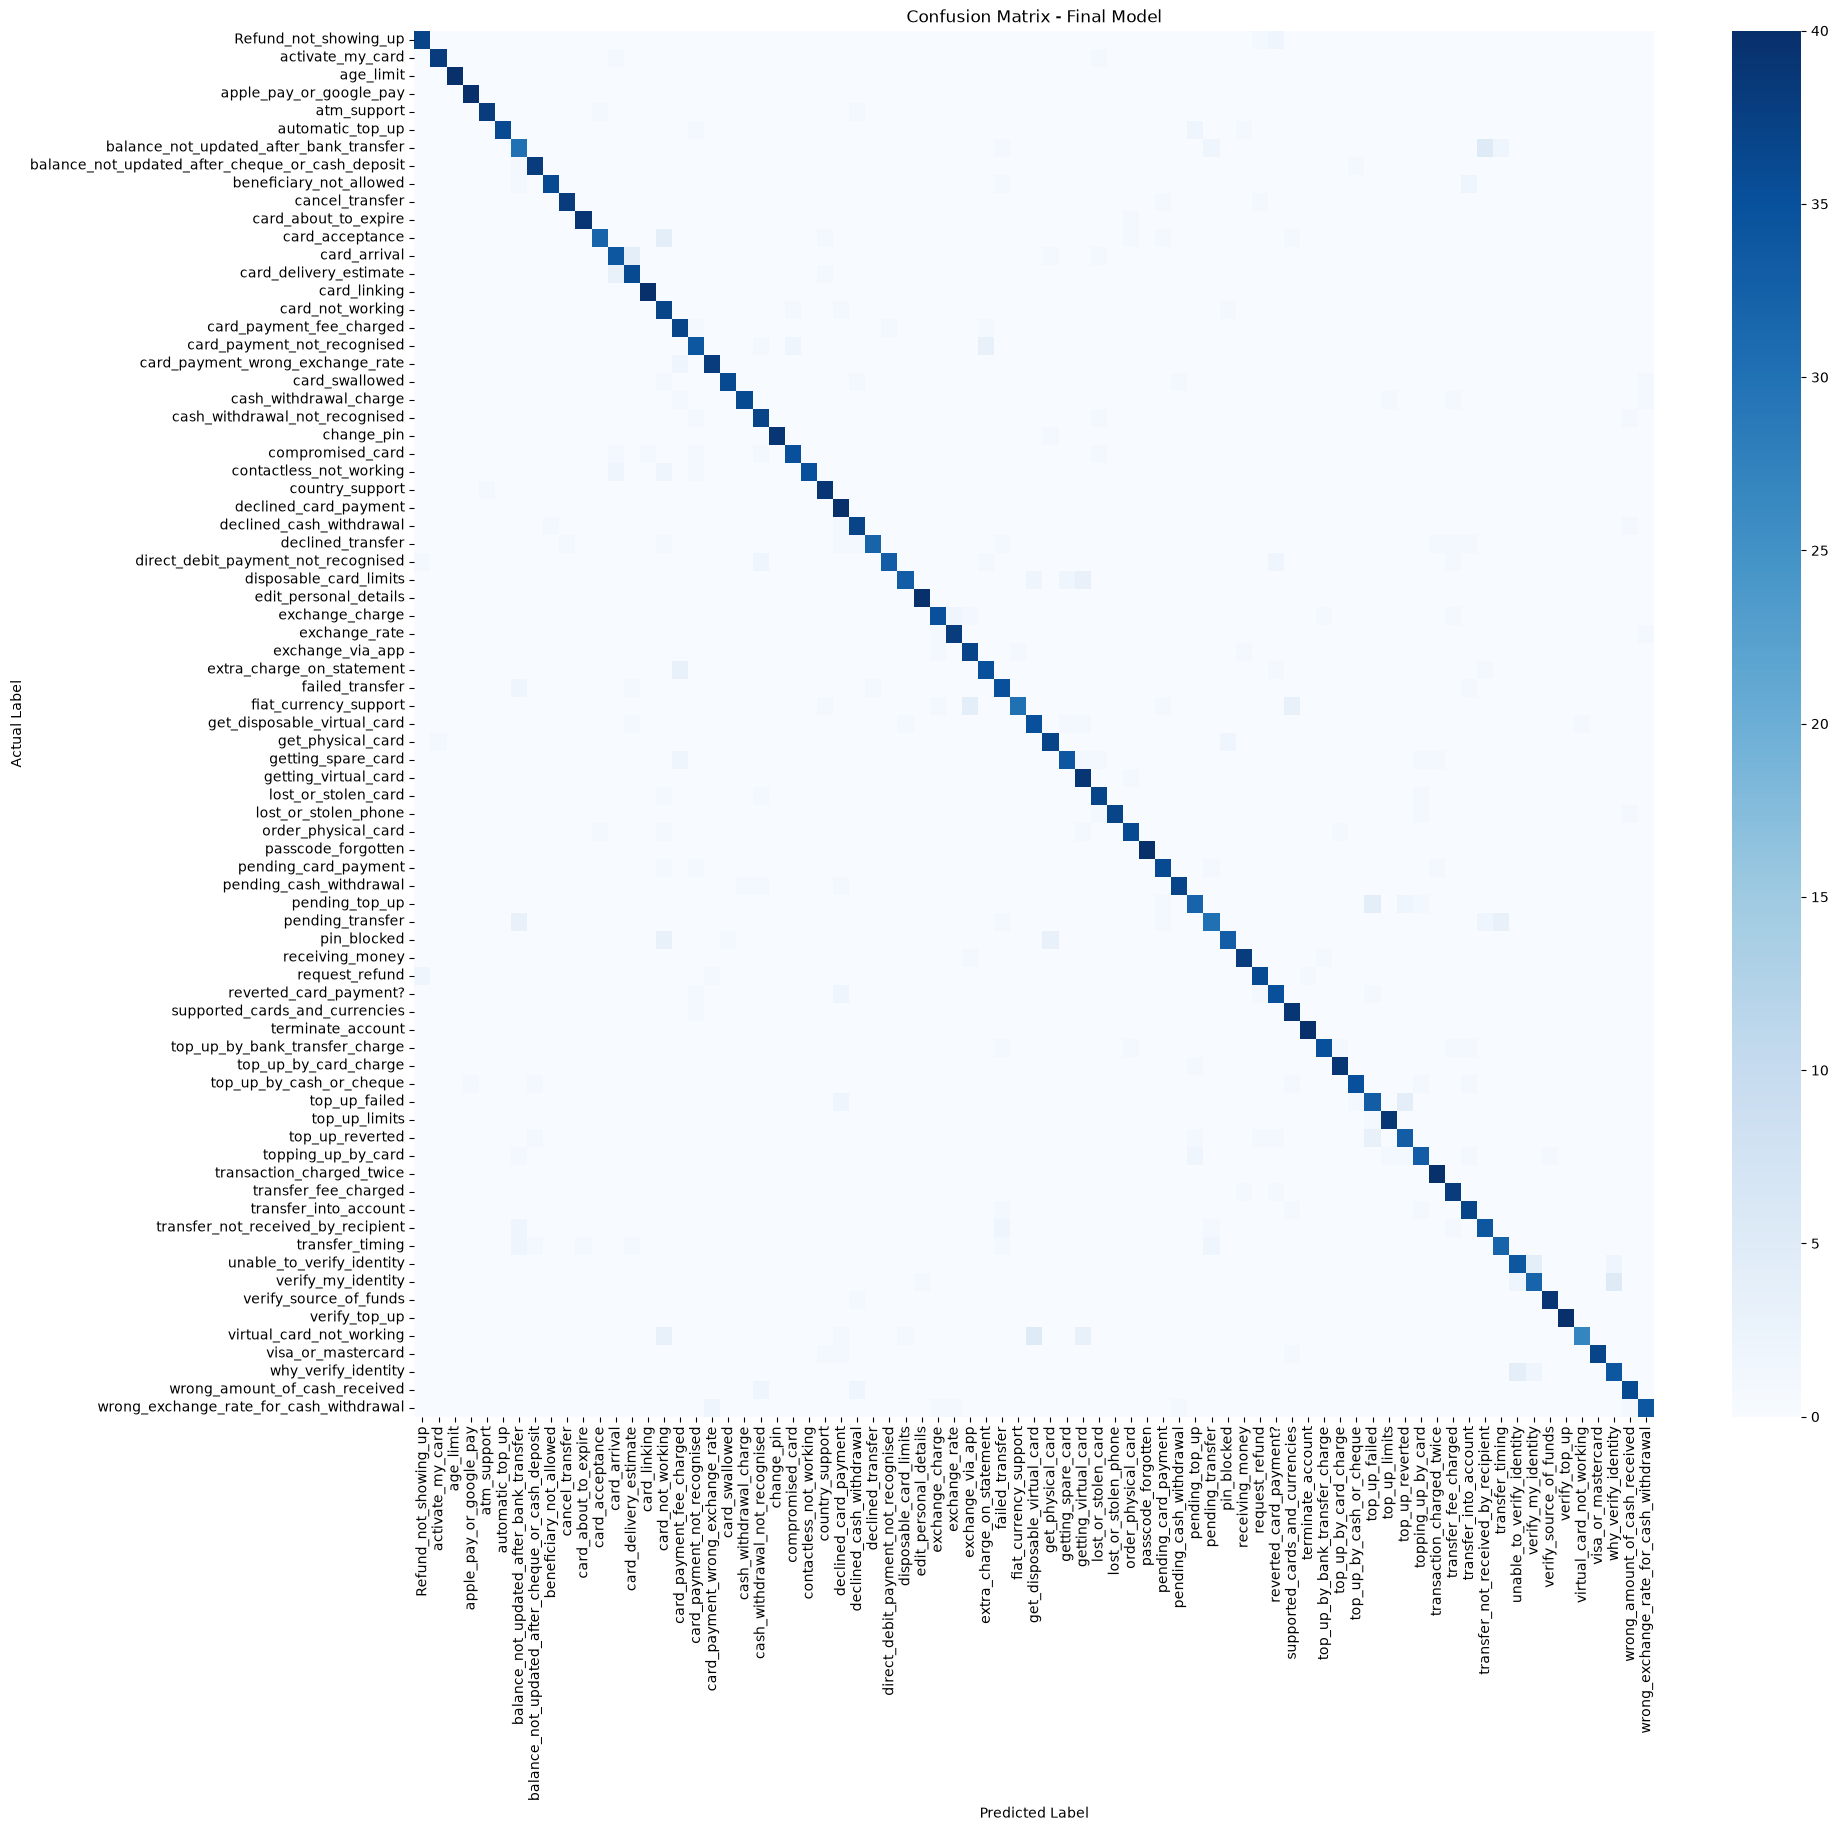

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, final_predictions, labels=final_model.classes_)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Final Model")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

error analysis

In [27]:
error_df = test_df.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = final_predictions

errors = error_df[
    error_df["actual"] != error_df["predicted"]
]

print("Total test samples:", len(test_df))
print("Total errors:", len(errors))
print(
    "Error rate:",
    len(errors) / len(test_df)
)

errors[["text", "actual", "predicted"]].head(20)

Total test samples: 3080
Total errors: 308
Error rate: 0.1


,text,actual,predicted
0,How do I locate my card?,card_arrival,get_physical_card
5,When will I get my card?,card_arrival,card_delivery_estimate
11,How long does a card delivery take?,card_arrival,card_delivery_estimate
26,I think something went wrong with my card deli...,card_arrival,card_delivery_estimate
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate
36,I'm starting to think my card is lost because ...,card_arrival,lost_or_stolen_card
93,Is it a good time to exchange?,exchange_rate,exchange_charge
106,The exchange rate would be?,exchange_rate,wrong_exchange_rate_for_cash_withdrawal
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged
150,the conversion value for my card payments is i...,card_payment_wrong_exchange_rate,card_payment_fee_charged


most confused categories

In [28]:
confusion_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(15)

,actual,predicted,count
204,virtual_card_not_working,get_disposable_virtual_card,5
11,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,5
199,verify_my_identity,why_verify_identity,5
167,top_up_failed,top_up_reverted,4
21,card_acceptance,card_not_working,4
209,why_verify_identity,unable_to_verify_identity,4
99,fiat_currency_support,exchange_via_app,4
26,card_arrival,card_delivery_estimate,4
133,pending_top_up,top_up_failed,4
195,unable_to_verify_identity,verify_my_identity,4


which categories perform poorly

In [29]:
report = classification_report(
    y_test,
    final_predictions,
    output_dict=True,
    zero_division=0
)

class_report_df = pd.DataFrame(report).T

class_report_df = class_report_df[
    ~class_report_df.index.isin(
        ["accuracy", "macro avg", "weighted avg"]
    )
]

class_report_df.sort_values(
    "f1-score",
    ascending=True
).head(15)

,precision,recall,f1-score,support
balance_not_updated_after_bank_transfer,0.714286,0.750,0.731707,40.0
card_not_working,0.685185,0.925,0.787234,40.0
pending_transfer,0.833333,0.750,0.789474,40.0
virtual_card_not_working,0.964286,0.675,0.794118,40.0
top_up_failed,0.785714,0.825,0.804878,40.0
verify_my_identity,0.842105,0.800,0.820513,40.0
pending_top_up,0.842105,0.800,0.820513,40.0
top_up_reverted,0.825000,0.825,0.825000,40.0
card_payment_not_recognised,0.809524,0.850,0.829268,40.0
transfer_not_received_by_recipient,0.809524,0.850,0.829268,40.0


final model

In [30]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/customer_support_classifier.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
